# VISTA Benchmark — Walkthrough

A guided tour of the full VISTA evaluation pipeline:

1. **Dataset structure** — 10 tasks, what each one looks like
2. **Conditions deep dive** — exactly what c0 / c1 / c2 / c3 / c4 give the agent, and why
3. **Ground-truth anchors** — the UI anchors used for scoring
4. **Interaction annotations** — the behavior taxonomy
5. **Scoring logic** — how L × B is computed
6. **Visualisation** — anchor bboxes overlaid on Figma screenshots

In [1]:
import json, re, difflib
from pathlib import Path
from collections import Counter

DATASET = Path('dataset')

def load_anchors(task_id):
    d = DATASET / task_id
    cleaned = d / f'{task_id}_anchors.cleaned.json'
    return json.load(open(cleaned if cleaned.exists() else d / f'{task_id}_anchors.json'))


## 1. Dataset Structure

In [2]:
with open(DATASET / 'tasks.jsonl') as f:
    tasks = [json.loads(l) for l in f if l.strip()]

with open(DATASET / 'samples.jsonl') as f:
    samples = [json.loads(l) for l in f if l.strip()]

print(f'{len(tasks)} tasks, {len(samples)} samples total')
print(f'Conditions: {dict(Counter(s["condition"] for s in samples))}')
print(f'c1 picks:   {dict(Counter(s.get("pick") for s in samples if s["condition"]=="c1"))}\n')

print(f'{"Task":42s} {"Pages":>6}  {"Anchors":>8}')
print('-' * 60)
for t in tasks:
    anc = load_anchors(t['task_id'])
    n = sum(len(v) for v in anc['anchors'].values())
    print(f"{t['task_id']:42s} {t['num_pages']:6d}  {n:8d}")


10 tasks, 60 samples total
Conditions: {'c0': 10, 'c1': 30, 'c2': 10, 'c3': 10}
c1 picks:   {'A': 10, 'B': 10, 'C': 10}

Task                                        Pages   Anchors
------------------------------------------------------------
1_newsletter                                    9        31
2_real-estate                                  14        64
3_job-board                                    19        74
4_forum                                         5        17
5_travel-booking                                8        29
6_chat                                         10        33
7_cloud-storage                                33       117
8_ecommerce                                     7        28
9_project-management                           10        29
10_streaming_music-streaming                   13        36


## 2. Conditions Deep Dive

VISTA has five evaluation conditions. They vary along **two independent axes**:

| | c0 | c1 | c2 | c3 | c4 |
|---|:---:|:---:|:---:|:---:|:---:|
| Text description | yes | yes | yes | yes | yes |
| Figma screenshots | — | yes | yes | yes | yes |
| Figma structure JSON | — | — | — | yes | yes |
| Framework prescribed | — | yes | — | — | — |
| Scaffold pre-seeded | — | yes | — | — | — |

**Axis 1 — Visual spec richness**: c0 < c2 < c3 = c4  
**Axis 2 — Engineering scaffolding**: c2 < c1

> c4 is the **leaderboard condition**: maximum visual spec, agent picks its own stack.

---

### c0 — Text only
The agent receives a single `description.md`. Every UI anchor is embedded inline as a
`<tag>` marker so the agent knows what elements to create, but has no visual reference
for exact positions. Localization (L) scores are naturally lower here — the agent must
infer layout from prose alone.

### c1 — Screenshots + prescribed framework + scaffold (picks A / B / C)
Same text as c0, plus the Figma screenshots, **plus** a `## Stack:` section at the bottom
of `description.md` that names the framework and gives the exact scaffold command.
The scaffold files are pre-seeded into `workspace/` so the agent skips that step entirely.
Three picks (A / B / C) assign different frameworks (e.g. Astro, Eleventy, Next.js) to
the same task — this isolates the effect of framework choice on final score.

### c2 — Screenshots only
Same text as c0, plus the Figma screenshots. No framework hint, no scaffold.
The screenshots give the agent a pixel-level visual reference, improving Localization
without prescribing any engineering choices.

### c3 — Screenshots + Figma structure JSON
Adds `*_structure-only.json` files for every page alongside the PNGs. These JSON files
contain the pruned Figma node tree — layer names, types, bounding boxes, and nesting — but
no images. They let a capable agent reconstruct the exact component hierarchy.
`description.md` also gains per-page pointers: Figma node id, screenshot path, and JSON path.

### c4 — Same inputs as c3, different scaffolding instruction
The **input files are identical to c3** (screenshots + structure JSON). The only
difference is in the system prompt's `[SCAFFOLDING]` section:

| | c3 | c4 |
|---|---|---|
| description.md | prescribes a scaffold command | prescribes **no** command |
| System prompt | "execute the given command first" | "pick your own stack, use any scaffold" |
| Failure rule | skipping the scaffold is a hard failure | no prescribed stack to skip |

c4 is the leaderboard condition because it most closely mirrors real-world agent use:
a rich visual spec is available but the agent must exercise judgment about the tech stack.

In [3]:
# Verify: c3 and c4 share the exact same input files
TASK = '1_newsletter'

def list_files(cond, pick=None):
    if cond == 'c1':
        base = DATASET / 'c1' / f'pick_{pick}' / TASK
    else:
        base = DATASET / cond / TASK
    if not base.exists():
        return set()
    return {str(p.relative_to(base)) for p in base.rglob('*') if p.is_file()}

c3_files = list_files('c3')
c4_files = list_files('c4') if (DATASET / 'c4').exists() else None

if c4_files is not None:
    print('c3 \ c4 (only in c3):', c3_files - c4_files)
    print('c4 \ c3 (only in c4):', c4_files - c3_files)
else:
    # c4 has no separate input folder — it reuses c3's inputs at runtime
    print('No separate c4/ input folder found.')
    print('c4 reuses c3 inputs at runtime; the only difference is the system prompt.')
    print()

# Show file counts per condition
for cond, pick in [('c0', None), ('c1', 'A'), ('c2', None), ('c3', None)]:
    files = list_files(cond, pick)
    label = f'c1/pick_{pick}' if cond == 'c1' else cond
    print(f'[{label}]  {len(files):3d} files')
    for f in sorted(files)[:6]:
        print(f'   {f}')
    if len(files) > 6:
        print(f'   ... (+{len(files)-6} more)')
    print()


No separate c4/ input folder found.
c4 reuses c3 inputs at runtime; the only difference is the system prompt.

[c0]    1 files
   description.md

[c1/pick_A]   46 files
   description.md
   pages/01_Home.png
   pages/02_Single-post.png
   pages/03_Author.png
   pages/04_Category.png
   pages/05_Tag.png
   ... (+40 more)

[c2]   10 files
   description.md
   pages/01_Home.png
   pages/02_Single-post.png
   pages/03_Author.png
   pages/04_Category.png
   pages/05_Tag.png
   ... (+4 more)

[c3]   19 files
   description.md
   pages/01_Home.png
   pages/01_Home_structure-only.json
   pages/02_Single-post.png
   pages/02_Single-post_structure-only.json
   pages/03_Author.png
   ... (+13 more)



In [4]:
# The only c3 -> c4 difference: system prompt diff (SCAFFOLDING section)
import subprocess
result = subprocess.run(
    ['diff', str(DATASET / 'agent_system_promt_c3.md'),
             str(DATASET / 'agent_system_promt_c4.md')],
    capture_output=True, text=True
)
print(result.stdout)


1c1
< # Agent System Prompt — Web App Code Generation & Deployment
---
> # Agent System Prompt — Web App Code Generation & Deployment (variant **c4**)
2a3,8
> > **Difference vs `agent_system_promt_c3.md`:**
> > The `[SCAFFOLDING]` section is rewritten — **no scaffold command is provided
> > in the task description for c4**. Pick a framework and bootstrap method
> > yourself, based on what best fits the mockup and described behavior.
> > All other constraints (visual fidelity, testid contract, verification,
> > etc.) are unchanged.
14c20
< ## [SCAFFOLDING] — read BEFORE writing code
---
> ## [SCAFFOLDING] — your call to make
16c22
< If the task description provides a scaffolding command (`npx create-next-app@latest …`, `npm create astro@latest …`, `npm create vite@latest …`, `git clone <starter>`, etc.), **execute it first** as the project foundation.
---
> The task description does NOT prescribe a framework or scaffold command. **You pick the stack** based on the task's nature:
18,22c2

In [5]:
# c0 description embeds anchor tags inline (<search>, <home>, ...)
desc_c0 = (DATASET / 'c0' / TASK / 'description.md').read_text()
desc_c3 = (DATASET / 'c3' / TASK / 'description.md').read_text()

tags = re.findall(r'<([a-z][a-z0-9_-]*)>', desc_c0)
print('Anchor tags in c0 description.md:', tags)

# c3 description additionally points to screenshots and structure JSON per page
extras = [l.strip() for l in desc_c3.splitlines()
          if any(k in l for k in ('Figma node', 'Reference snapshot', 'Structure JSON'))]
print('\nExtra per-page pointers in c3 (first 6):')
for l in extras[:6]:
    print(' ', l)

# c1 additionally appends a ## Stack section
desc_c1 = (DATASET / 'c1' / 'pick_A' / TASK / 'description.md').read_text()
stack_section = desc_c1[desc_c1.rfind('## Stack'):]
print('\nStack section appended in c1/pick_A:')
print(stack_section)


Anchor tags in c0 description.md: ['search', 'home', 'title', 'subscribe', 'home', 'login', 'submit', 'category-nature', 'home', 'contact-us', 'article', 'service', 'article', 'article', 'home', 'contact-us', 'article', 'home', 'contact-us', 'article', 'your-email', 'home', 'search', 'article', 'home', 'your-name', 'your-email', 'subscribe', 'home', 'search', 'send-message', 'starter']

Extra per-page pointers in c3 (first 6):
  - **Figma node:** `19079-25669`
  - **Reference snapshot:** `pages/01_Home.png`
  - **Structure JSON:** `pages/01_Home_structure-only.json`
  - **Figma node:** `19195-54698`
  - **Reference snapshot:** `pages/02_Single-post.png`
  - **Structure JSON:** `pages/02_Single-post_structure-only.json`

Stack section appended in c1/pick_A:
## Stack: Astro

```bash
npm create astro@latest -- --template blog
```


## 3. Ground-Truth Anchors

Each task ships with a set of **critical UI anchors** annotated by humans.
An anchor is a specific interactive element on a specific page, identified by:

- `testid` — the `data-testid` the generated app must use (the agent is told to wire these up)
- `bbox_png` — its bounding box in the Figma PNG (used for Localization scoring)
- `reasoning` — why this element was selected and what behavior is expected

In [6]:
anchors_data = load_anchors(TASK)

total = 0
for page, ancs in anchors_data['anchors'].items():
    total += len(ancs)
    print(f'[{page}]  {len(ancs)} anchor(s)')
    for a in ancs:
        b = a['bbox_png']
        print(f"  {a['testid']:20s}  bbox=({b['x']},{b['y']},{b['w']},{b['h']})  {a['reasoning'][:60]}")

print(f'\nTotal: {total} anchors')


[01_Home]  4 anchor(s)
  home                  bbox=(317,71,81,64)  Subscribe form frame — submitting triggers confirmation moda
  search                bbox=(2492,79,48,48)  "search" submits a search query and navigates to search resu
  subscribe             bbox=(1607,9796,932,119)  "Buttons/Button" is a button that likely triggers navigation
  title                 bbox=(1460,2776,1079,476)  
[02_Single-post]  4 anchor(s)
  login                 bbox=(2466,72,94,48)  "Buttons/Button" is a button that likely triggers navigation
  home                  bbox=(320,192,82,64)  
  submit                bbox=(320,6968,310,120)  "Buttons/Button" is a button that likely triggers navigation
  category-nature       bbox=(1856,2480,704,296)  
[03_Author]  3 anchor(s)
  home                  bbox=(1085,64,82,64)  "Frame" is an unclassified clickable element; defaulting to 
  contact-us            bbox=(2218,52,230,88)  "Buttons/Button" is a button that likely triggers navigation
  article       

## 4. Interaction Annotations

Each clickable element on each page is classified into a **behavior subtype**.
This taxonomy drives the Behavior (B) score: the evaluator knows what to expect
when it triggers the element in the live app.

In [7]:
interaction_dir = DATASET / TASK / 'interaction'

subtype_total = Counter()
for f in sorted(interaction_dir.glob('*_click_subtype.json')):
    d = json.load(open(f))
    subtypes = {k: v for k, v in d['subtypes'].items() if v > 0}
    subtype_total.update(subtypes)
    print(f"[{d['page_name']}]  total_clicks={d['total_click']}  {subtypes}")

print('\nDataset-wide totals:', dict(subtype_total))


[01_Home]  total_clicks=7  {'click_dead': 1, 'click_popout': 4, 'click_unknown_nav': 2}
[02_Single-post]  total_clicks=5  {'click_unknown_nav': 5}
[03_Author]  total_clicks=5  {'click_unknown_nav': 5}
[04_Category]  total_clicks=4  {'click_unknown_nav': 4}
[05_Tag]  total_clicks=7  {'click_external': 2, 'click_unknown_nav': 5}
[06_Date]  total_clicks=12  {'click_external': 4, 'click_unknown_nav': 8}
[07_Search]  total_clicks=5  {'click_unknown_nav': 5}
[08_About_me]  total_clicks=4  {'click_unknown_nav': 4}
[09_Contact_me]  total_clicks=4  {'click_unknown_nav': 4}

Dataset-wide totals: {'click_dead': 1, 'click_popout': 4, 'click_unknown_nav': 42, 'click_external': 6}


In [8]:
SUBTYPE_DESC = {
    'click_dead'        : 'Click lands on an inert zone — no response expected',
    'click_popout'      : 'Click opens a modal / popover / toast',
    'click_external'    : 'Click navigates to an external URL (new tab)',
    'click_unknown_nav' : 'Click navigates to a page outside the dataset scope',
    'click_social_oauth': 'Triggers a social OAuth redirect (Google, Facebook, ...)',
    'click_upload_file' : 'Opens a file-picker for upload',
    'click_play_music'  : 'Starts audio playback',
    'click_vol'         : 'Controls audio volume',
    'click_next_music'  : 'Skips to next track',
    'click_pre_music'   : 'Goes back to previous track',
}

print(f'{"Subtype":25s}  Description')
print('-' * 70)
for k, v in SUBTYPE_DESC.items():
    mark = '  <-- appears in this task' if k in subtype_total else ''
    print(f'{k:25s}  {v}{mark}')


Subtype                    Description
----------------------------------------------------------------------
click_dead                 Click lands on an inert zone — no response expected  <-- appears in this task
click_popout               Click opens a modal / popover / toast  <-- appears in this task
click_external             Click navigates to an external URL (new tab)  <-- appears in this task
click_unknown_nav          Click navigates to a page outside the dataset scope  <-- appears in this task
click_social_oauth         Triggers a social OAuth redirect (Google, Facebook, ...)
click_upload_file          Opens a file-picker for upload
click_play_music           Starts audio playback
click_vol                  Controls audio volume
click_next_music           Skips to next track
click_pre_music            Goes back to previous track


## 5. Scoring Logic

```
per-anchor score  =  L  x  B
app score         =  mean(per-anchor scores)
combined score S  =  mean(app scores across all 10 tasks)
```

**L — Localization**: Can the evaluator find an element with the right `data-testid`
in the live DOM, and is its bounding box close enough to the Figma ground truth
(measured by IoU / centre-distance)?

**B — Behavior**: Does triggering the element produce the expected response?
What counts as a pass depends on the subtype:
- `click_popout` → a modal/overlay appears
- `click_unknown_nav` → any client-side navigation fires
- `click_external` → link opens an external URL
- `click_dead` → element exists but produces no action (intentionally inert)

Because the score is a **product**, an app that looks right but is completely broken
scores near zero — behavior is typically the harder bottleneck.

In [9]:
def mock_score(anchors_by_page, loc, beh):
    rows = []
    for page, ancs in anchors_by_page.items():
        for a in ancs:
            key = (page, a['testid'])
            L, B = loc.get(key, 0.0), beh.get(key, 0.0)
            rows.append({'page': page, 'testid': a['testid'], 'L': L, 'B': B, 'LxB': L * B})
    return rows

import random
random.seed(42)
anc = anchors_data['anchors']

# Scenario A: L mostly good, B only ~50%
loc_a  = {(p, a['testid']): random.uniform(0.6, 1.0) for p, acs in anc.items() for a in acs}
beh_a  = {(p, a['testid']): random.choice([0.0, 0.0, 1.0]) for p, acs in anc.items() for a in acs}
rows_a = mock_score(anc, loc_a, beh_a)

# Scenario B: L missing several elements (0), B perfect where found
loc_b  = {(p, a['testid']): random.choice([0.0, 0.8, 0.9, 1.0]) for p, acs in anc.items() for a in acs}
beh_b  = {(p, a['testid']): 1.0 for p, acs in anc.items() for a in acs}
rows_b = mock_score(anc, loc_b, beh_b)

print(f'Scenario A (good L, weak B):  app score = {sum(r["LxB"] for r in rows_a)/len(rows_a):.3f}')
print(f'Scenario B (partial L, good B): app score = {sum(r["LxB"] for r in rows_b)/len(rows_b):.3f}')

print(f'\n{"page":20s} {"testid":20s} {"L":6s} {"B":6s} {"LxB":6s}')
print('-' * 62)
for r in rows_a:
    print(f"{r['page']:20s} {r['testid']:20s} {r['L']:.3f}  {r['B']:.1f}  {r['LxB']:.3f}")


Scenario A (good L, weak B):  app score = 0.242
Scenario B (partial L, good B): app score = 0.806

page                 testid               L      B      LxB   
--------------------------------------------------------------
01_Home              home                 0.856  1.0  0.856
01_Home              search               0.610  0.0  0.000
01_Home              subscribe            0.710  1.0  0.710
01_Home              title                0.689  0.0  0.000
02_Single-post       login                0.895  0.0  0.000
02_Single-post       home                 0.871  0.0  0.000
02_Single-post       submit               0.957  1.0  0.957
02_Single-post       category-nature      0.635  0.0  0.000
03_Author            home                 0.769  1.0  0.769
03_Author            contact-us           0.612  1.0  0.612
03_Author            article              0.687  0.0  0.000
04_Category          service              0.802  1.0  0.802
04_Category          article              0.680  1.0  0

## 6. Visualisation — Anchor Bboxes on Figma Screenshots

Each coloured rectangle is one anchor. The label is its `testid`.

In [10]:
try:
    from PIL import Image
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    PIL_OK = True
except ImportError:
    print('Pillow not installed: pip install Pillow')
    PIL_OK = False


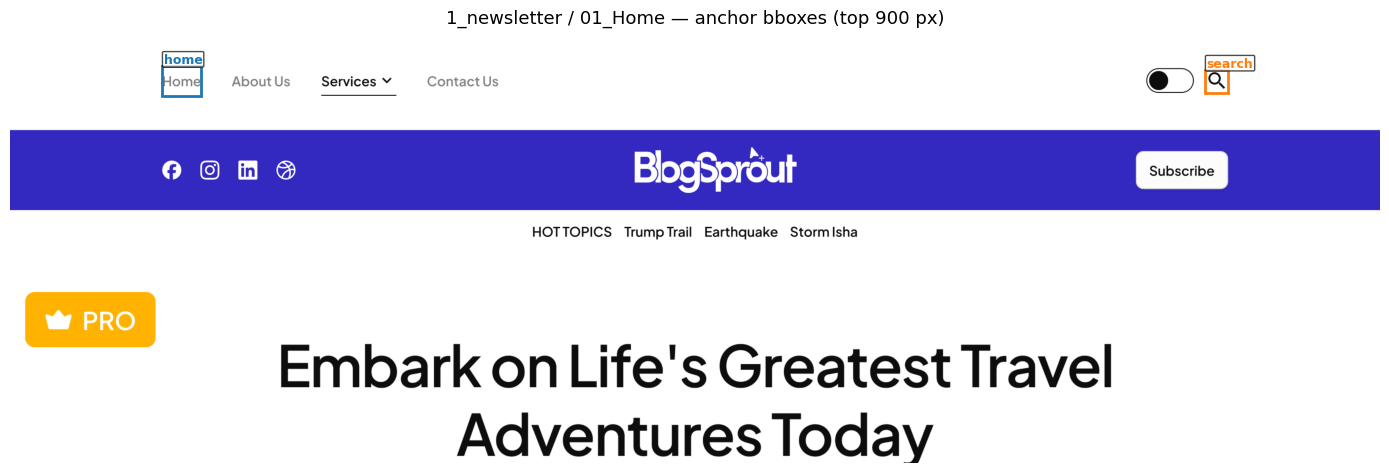

In [11]:
if PIL_OK:
    PAGE = '01_Home'
    img = Image.open(DATASET / TASK / 'pages' / '01_Home.png')
    W, H = img.size
    crop_h = 900

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(img.crop((0, 0, W, crop_h)))
    ax.set_title(f'{TASK} / {PAGE} — anchor bboxes (top {crop_h} px)', fontsize=13)

    colors = plt.cm.tab10.colors
    for i, a in enumerate(anchors_data['anchors'][PAGE]):
        b = a['bbox_png']
        if b['y'] > crop_h:
            continue
        c = colors[i % len(colors)]
        ax.add_patch(patches.Rectangle(
            (b['x'], b['y']), b['w'], b['h'],
            linewidth=2, edgecolor=c, facecolor='none'
        ))
        ax.text(b['x'] + 3, b['y'] - 6, a['testid'], color=c, fontsize=9,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.7))
    ax.axis('off')
    plt.tight_layout()
    plt.show()


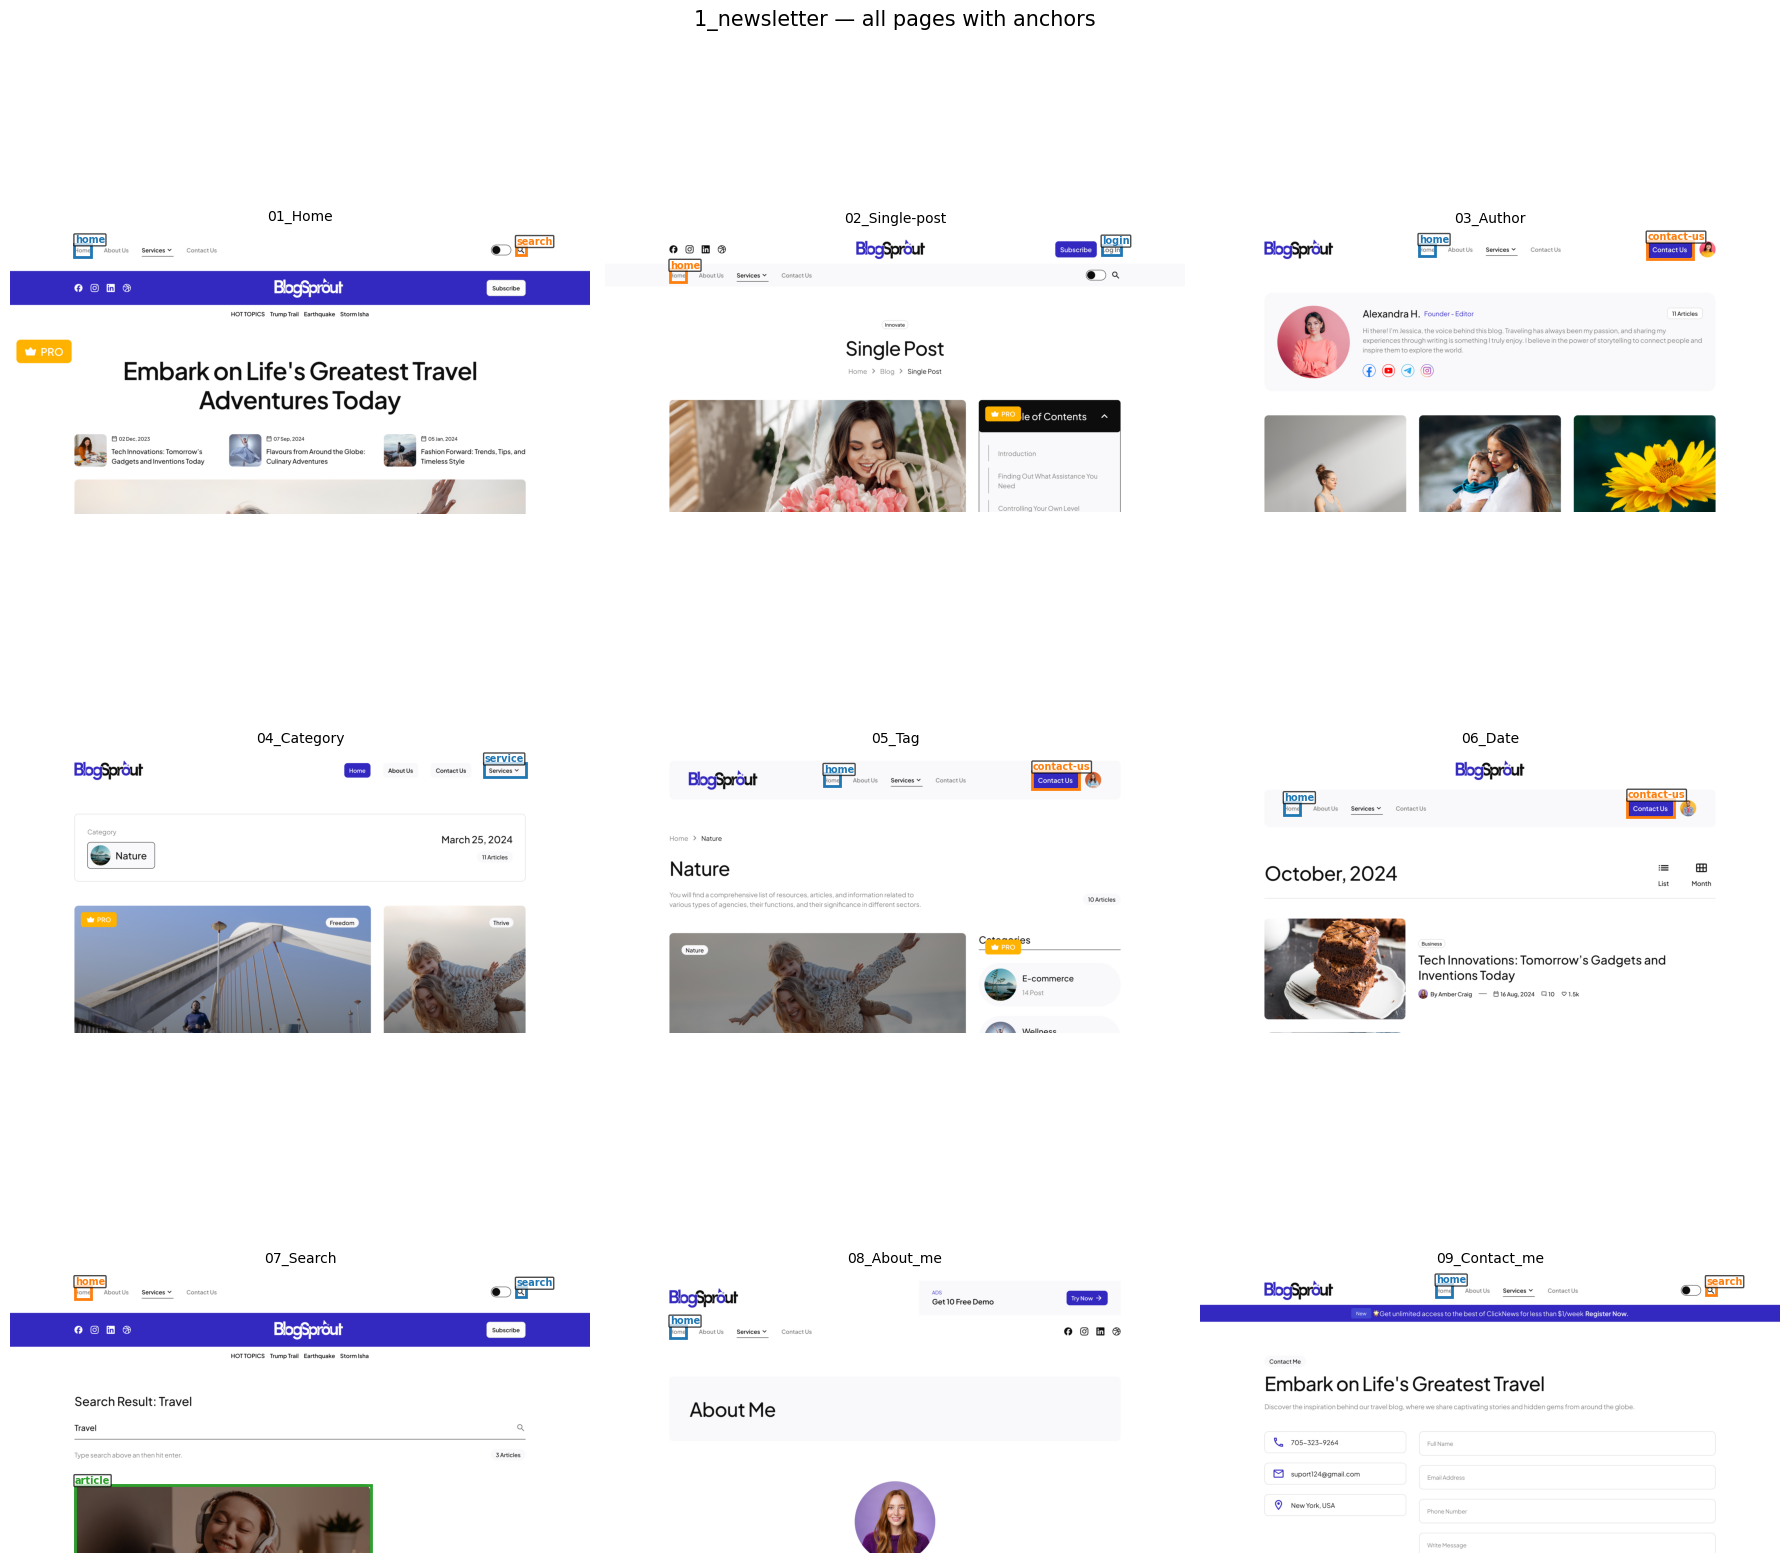

In [12]:
# All pages at once
if PIL_OK:
    pages_dir = DATASET / TASK / 'pages'
    page_keys = list(anchors_data['anchors'].keys())
    png_map = {
        '01_Home': '01_Home.png', '02_Single-post': '02_Single-post.png',
        '03_Author': '03_Author.png', '04_Category': '04_Category.png',
        '05_Tag': '05_Tag.png', '06_Date': '06_Date.png',
        '07_Search': '07_Search.png', '08_About_me': '08_About_me.png',
        '09_Contact_me': '09_Contact_me.png',
    }

    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    fig.suptitle(f'{TASK} — all pages with anchors', fontsize=15)
    colors = plt.cm.tab10.colors

    for ax, page in zip(axes.flat, page_keys):
        png = pages_dir / png_map.get(page, '')
        if not png.exists():
            ax.set_visible(False); continue
        img = Image.open(png)
        W, H = img.size
        crop_h = min(H, 1400)
        ax.imshow(img.crop((0, 0, W, crop_h)))
        ax.set_title(page, fontsize=10)
        for i, a in enumerate(anchors_data['anchors'][page]):
            b = a['bbox_png']
            if b['y'] >= crop_h: continue
            c = colors[i % len(colors)]
            ax.add_patch(patches.Rectangle(
                (b['x'], b['y']), b['w'], b['h'],
                linewidth=2, edgecolor=c, facecolor='none'
            ))
            ax.text(b['x']+2, b['y']-5, a['testid'], color=c, fontsize=7,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.7))
        ax.axis('off')

    plt.tight_layout()
    plt.show()


## 7. Anchor Count per Task

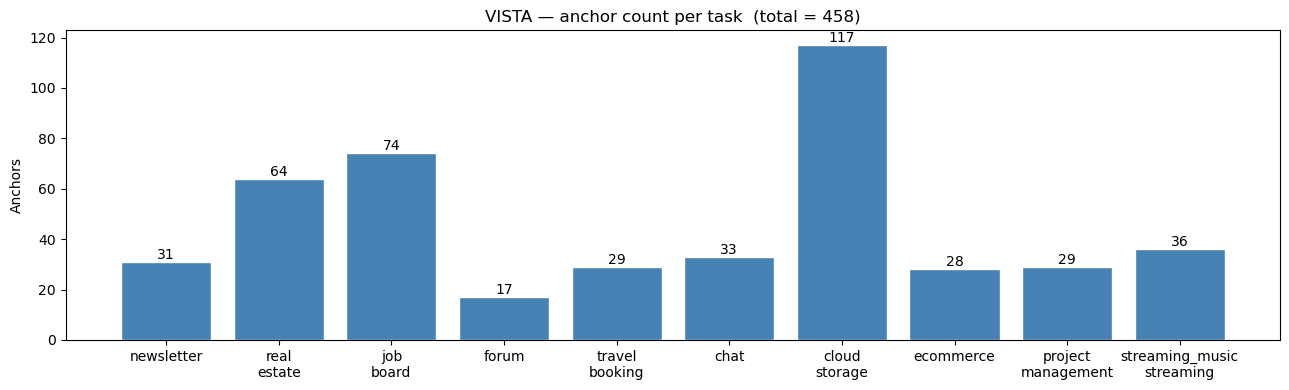

Total : 458
Min   : 17  (4_forum)
Max   : 117  (7_cloud-storage)


In [13]:
import matplotlib.pyplot as plt

anchor_counts = []
for t in tasks:
    d = load_anchors(t['task_id'])
    anchor_counts.append(sum(len(v) for v in d['anchors'].values()))

short_names = [t['task_id'].split('_', 1)[1].replace('-', '\n') for t in tasks]

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(short_names, anchor_counts, color='steelblue', edgecolor='white')
ax.bar_label(bars)
ax.set_ylabel('Anchors')
ax.set_title(f'VISTA — anchor count per task  (total = {sum(anchor_counts)})')
plt.tight_layout()
plt.show()

print(f'Total : {sum(anchor_counts)}')
print(f'Min   : {min(anchor_counts)}  ({tasks[anchor_counts.index(min(anchor_counts))]["task_id"]})')
print(f'Max   : {max(anchor_counts)}  ({tasks[anchor_counts.index(max(anchor_counts))]["task_id"]})')


## 8. Quick Task Explorer

Change `task_id` to explore any of the 10 tasks.

In [14]:
def task_summary(task_id):
    t = next(x for x in tasks if x['task_id'] == task_id)
    d = load_anchors(task_id)
    n = sum(len(v) for v in d['anchors'].values())
    print(f"Task      : {t['task_title']}")
    print(f"Brand     : {t['brand']}")
    print(f"Analogues : {t['real_world_analogues']}")
    print(f"Pages     : {t['num_pages']}    Anchors: {n}")
    print()
    for page, ancs in d['anchors'].items():
        print(f"  {page:28s} {[a['testid'] for a in ancs]}")

# Available task IDs:
# 1_newsletter  2_real-estate  3_job-board  4_forum  5_travel-booking
# 6_chat  7_cloud-storage  8_ecommerce  9_project-management  10_streaming_music-streaming
task_summary('4_forum')


Task      : Task 7 — Forum / Q&A Site
Brand     : *alemhelp* — a coding Q&A platform for a programming school
Analogues : Reddit, Stack Overflow, Hacker News
Pages     : 5    Anchors: 17

  01_Register                  ['register', 'username', 'passwd']
  02_Login                     ['login', 'username']
  03_Main                      ['search', 'profile', 'likes', 'card']
  04_Post_View                 ['search', 'profile', 'suggest', 'like']
  05_Post_Edit                 ['search', 'profile', 'publish', 'like']
